# Lo & Pachamanova (2015) — Reproduce Pipeline

Replication của paper *From predictive uplift modeling to prescriptive uplift analytics*.

**Pipeline (6 bước):**
1. Train/Holdout split (holdout = 18,985)
2. Separate Model Approach — 3 Logistic Regression → lift scores
3. KMeans K=10 → merge 2 nhỏ nhất → 9 clusters → **Table 3 LP** → Figure 1
4. Bootstrap S=60 → **Table 4** (percentiles + SD) + **Table 5** (correlation)
5. MVO sweep λ → **Figure 2** (Efficient Frontier)
6. MVO constrained → **Table 6** (risk-averse solution)

In [1]:
# =============================================================================
# IMPORTS & SETUP
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from scipy.optimize import minimize
import pulp, os

np.random.seed(42)

OUTPUT_DIR = '/kaggle/working'
os.makedirs(OUTPUT_DIR, exist_ok=True)
def out(f): return os.path.join(OUTPUT_DIR, f)

plt.rcParams.update({'font.family':'DejaVu Sans','font.size':10,
                     'axes.titlesize':12,'axes.titleweight':'bold',
                     'axes.spines.top':False,'axes.spines.right':False,
                     'figure.dpi':130,'savefig.dpi':130,'savefig.bbox':'tight'})
COLORS = {'mens':'#2563EB','womens':'#DC2626','control':'#6B7280',
          'accent':'#F59E0B','good':'#059669','bg':'#F8FAFC'}

# =============================================================================
# PARAMETERS  (theo paper Lo & Pachamanova 2015)
# =============================================================================
BUDGET      = 60_000   # $60K budget
COST_PER    = 1.0      # $1 per mailing
S           = 60       # số bootstrap samples (paper dùng S=60)
FUTURE_MULT = 10       # future data = 10x holdout (paper assumption)
K_KMEANS    = 10       # paper dùng k-means K=10, sau đó merge
K_FINAL     = 9        # sau khi merge 2 cluster nhỏ nhất → 9 clusters
SPLIT_SEED  = 2        # random seed cho train/holdout split
KM_SEED     = 99       # random seed cho KMeans
TARGET_LIFT = 4000.0   # MVO target (Table 6)


In [2]:
# =============================================================================
# LOAD DATA — Kevin Hillstrom MineThatData (64,000 customers)
# Source: http://blog.minethatdata.com/2008/03/minethatdata-email-analytics-and-data.html
# Segments: Mens E-Mail | Womens E-Mail | No E-Mail (control)
# Response: visit (0/1)
# =============================================================================
df_raw = pd.read_csv(
    '/kaggle/input/datasets/phmththuvn/kevin-hillstrom/Kevin_Hillstrom_MineThatData.csv'
)
print(f"Dataset: {df_raw.shape}")
print(df_raw['segment'].value_counts())

ctrl = df_raw[df_raw.segment=='No E-Mail']['visit'].mean()
mens = df_raw[df_raw.segment=='Mens E-Mail']['visit'].mean()
woms = df_raw[df_raw.segment=='Womens E-Mail']['visit'].mean()
print(f"\nOverall lift mens  : {mens-ctrl:.4f}")
print(f"Overall lift womens: {woms-ctrl:.4f}")


Dataset: (64000, 12)
segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64

Overall lift mens  : 0.0766
Overall lift womens: 0.0452


In [3]:
# =============================================================================
# PREPROCESSING & TRAIN/HOLDOUT SPLIT
# Paper: data "randomly split into training sample and holdout sample"
# Holdout size = sum(n_future)/FUTURE_MULT = 189,850/10 = 18,985
# → test_size = 18,985 / 64,000 = 0.2966
# =============================================================================
le = LabelEncoder()
df_raw['zip_code_enc']    = le.fit_transform(df_raw['zip_code'])
df_raw['channel_enc']     = le.fit_transform(df_raw['channel'])
df_raw['history_seg_enc'] = le.fit_transform(df_raw['history_segment'])

FEATURES = ['recency','history','mens','womens','newbie',
            'zip_code_enc','channel_enc','history_seg_enc']

TEST_SIZE = 18_985 / 64_000   # ~30% holdout (paper implied)

df_train, df_hold = train_test_split(df_raw, test_size=TEST_SIZE, random_state=SPLIT_SEED)
df_train = df_train.reset_index(drop=True)
df_hold  = df_hold.reset_index(drop=True)

print(f"Train : {len(df_train):,}")
print(f"Holdout: {len(df_hold):,}  → n_future = {len(df_hold)*FUTURE_MULT:,}")

# Một scaler duy nhất fit trên toàn bộ training data
scaler  = StandardScaler().fit(df_train[FEATURES])
df_tr_m = df_train[df_train.segment=='Mens E-Mail'].reset_index(drop=True)
df_tr_w = df_train[df_train.segment=='Womens E-Mail'].reset_index(drop=True)
df_tr_c = df_train[df_train.segment=='No E-Mail'].reset_index(drop=True)
print(f"Train subsets — Mens:{len(df_tr_m):,}  Womens:{len(df_tr_w):,}  Ctrl:{len(df_tr_c):,}")


Train : 45,015
Holdout: 18,985  → n_future = 189,850
Train subsets — Mens:14,889  Womens:15,174  Ctrl:14,952


In [4]:
# =============================================================================
# STEP 1 — Separate Model Approach (Logistic Regression)
# Paper: "Standard logistic regression along with the stepwise procedure"
# Eq.(2): lift_ij = p(R|T_j, x_i) - p(R|C, x_i)
# Fit 3 models riêng: mens, womens, control
# Score trên HOLDOUT (unbiased estimates)
# =============================================================================
def fit_lr(df_seg):
    """Fit logistic regression trên một segment."""
    m = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
    m.fit(scaler.transform(df_seg[FEATURES]), df_seg['visit'].values)
    return m

model_m = fit_lr(df_tr_m)   # p(visit | Mens E-Mail)
model_w = fit_lr(df_tr_w)   # p(visit | Womens E-Mail)
model_c = fit_lr(df_tr_c)   # p(visit | No E-Mail = control)

# Score holdout: lift = p(treatment) - p(control)
Xh = scaler.transform(df_hold[FEATURES])
df_hold['lift_mens']   = model_m.predict_proba(Xh)[:,1] - model_c.predict_proba(Xh)[:,1]
df_hold['lift_womens'] = model_w.predict_proba(Xh)[:,1] - model_c.predict_proba(Xh)[:,1]

print(f"Model-based lift scores (holdout):")
print(f"  Mean lift mens  : {df_hold['lift_mens'].mean():.4f}")
print(f"  Mean lift womens: {df_hold['lift_womens'].mean():.4f}")


Model-based lift scores (holdout):
  Mean lift mens  : 0.0723
  Mean lift womens: 0.0452


In [5]:
# =============================================================================
# STEP 2 — Clustering-based Heuristic Algorithm (paper steps 1–4)
#
# Step 1: Compute model-based lift scores π̂_ij (done in previous cell)
# Step 2: KMeans K=10 trên lift scores
# Step 3: Tính OBSERVED cluster-level lift từ holdout response rates
#         π̂_kj = mean(visit|cluster=k, segment=T_j) - mean(visit|cluster=k, segment=ctrl)
# Step 4: Merge 2 cluster nhỏ nhất (paper footnote 9)
#         "two original clusters merged into cluster 1 due to low quantities"
# =============================================================================
km = KMeans(n_clusters=K_KMEANS, random_state=KM_SEED, n_init=20, max_iter=500)
raw_labels = km.fit_predict(df_hold[['lift_mens','lift_womens']].values)
df_hold['cluster_raw'] = raw_labels

# Step 3: Tính observed lift per cluster (từ actual response data)
rows10 = []
for k in range(K_KMEANS):
    idx = raw_labels == k
    ck  = df_hold[idx]
    cm  = ck[ck.segment=='Mens E-Mail']['visit']
    cw  = ck[ck.segment=='Womens E-Mail']['visit']
    cc  = ck[ck.segment=='No E-Mail']['visit']
    lm  = float(cm.mean()-cc.mean()) if (len(cm)>0 and len(cc)>0) else 0.0
    lw  = float(cw.mean()-cc.mean()) if (len(cw)>0 and len(cc)>0) else 0.0
    rows10.append({'raw_k':k, 'n':int(idx.sum()), 'lm':lm, 'lw':lw})

df10 = pd.DataFrame(rows10).sort_values('n').reset_index(drop=True)
print(f"10 raw cluster sizes: {sorted(df10['n'].tolist())}")

# Merge 2 cluster nhỏ nhất → weighted average lift
r0, r1 = df10.iloc[0], df10.iloc[1]
w0, w1 = float(r0['n']), float(r1['n'])
merged_raw_keys = {int(r0['raw_k']), int(r1['raw_k'])}
merged = {'raw_k':-1, 'n':w0+w1,
          'lm':(r0['lm']*w0 + r1['lm']*w1)/(w0+w1),
          'lw':(r0['lw']*w0 + r1['lw']*w1)/(w0+w1)}
print(f"Merge clusters {int(r0['raw_k'])} (n={int(w0)}) + {int(r1['raw_k'])} (n={int(w1)}) → n={int(w0+w1)}")

df_cl = pd.concat([pd.DataFrame([merged]), df10.iloc[2:]], ignore_index=True)
df_cl = df_cl.sort_values('lm', ascending=False).reset_index(drop=True)
df_cl['cluster']  = range(1, K_FINAL+1)
df_cl['n_future'] = (df_cl['n'] * FUTURE_MULT).astype(int)

# Remap cluster labels vào holdout dataframe
remap = {}
for _, row in df_cl.iterrows():
    if row['raw_k'] == -1:
        for rk in merged_raw_keys: remap[rk] = int(row['cluster'])
    else:
        remap[int(row['raw_k'])] = int(row['cluster'])
df_hold['cluster'] = df_hold['cluster_raw'].map(remap)

# Cluster dict để dùng ở LP và MVO
clusters = {int(r.cluster): {'n_future':int(r.n_future),
                              'lm':float(r['lm']), 'lw':float(r['lw'])}
            for _, r in df_cl.iterrows()}

print(f"\nCluster-level observed lift (input cho LP):")
print(f"{'Cluster':>8} {'n_holdout':>10} {'n_future':>10} {'lift_mens':>11} {'lift_womens':>12}")
for _, r in df_cl.iterrows():
    print(f"{int(r.cluster):>8} {int(r['n']):>10,} {int(r.n_future):>10,} {r['lm']:>11.3f} {r['lw']:>12.3f}")
print(f"\nTotal n_future: {df_cl.n_future.sum():,}")


10 raw cluster sizes: [424, 532, 592, 1152, 1175, 2092, 2262, 2758, 3912, 4086]
Merge clusters 7 (n=424) + 4 (n=532) → n=956

Cluster-level observed lift (input cho LP):
 Cluster  n_holdout   n_future   lift_mens  lift_womens
       1        592      5,920       0.197        0.066
       2      1,175     11,750       0.170        0.111
       3        956      9,560       0.150        0.066
       4      2,092     20,920       0.086        0.003
       5      3,912     39,120       0.077        0.068
       6      4,086     40,860       0.074        0.079
       7      1,152     11,520       0.063        0.005
       8      2,758     27,580       0.062        0.007
       9      2,262     22,620       0.059        0.012

Total n_future: 189,850


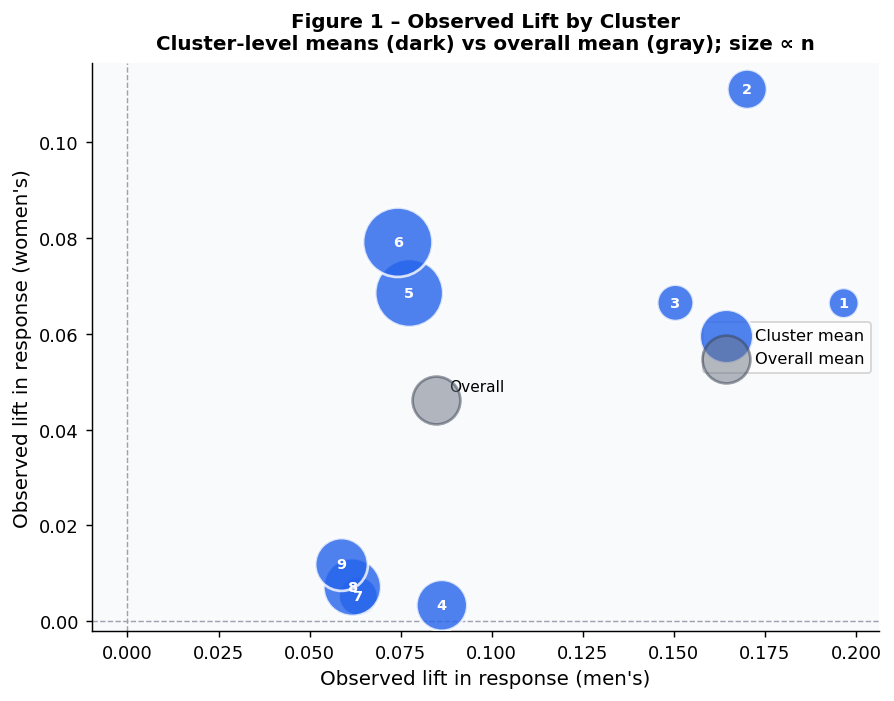

Saved fig1_bubble_chart.png


In [6]:
# =============================================================================
# FIGURE 1 — Bubble Chart: Observed Lift by Cluster
# "Cluster-level means (dark bubbles) vs overall sample mean (gray bubble)"
# Bubble size ∝ cluster sample size (paper description)
# =============================================================================
ov_m = (df_hold[df_hold.segment=='Mens E-Mail']['visit'].mean() -
        df_hold[df_hold.segment=='No E-Mail']['visit'].mean())
ov_w = (df_hold[df_hold.segment=='Womens E-Mail']['visit'].mean() -
        df_hold[df_hold.segment=='No E-Mail']['visit'].mean())

fig, ax = plt.subplots(figsize=(7, 5.5))
fig.patch.set_facecolor('white'); ax.set_facecolor(COLORS['bg'])

# Dark bubbles = cluster means, size ∝ n_holdout
sizes = (df_cl['n'] / df_cl['n'].max()) * 1400 + 80
ax.scatter(df_cl['lm'], df_cl['lw'], s=sizes, c=COLORS['mens'],
           alpha=0.8, edgecolors='white', linewidths=1.5, zorder=3, label='Cluster mean')
for _, row in df_cl.iterrows():
    ax.annotate(str(int(row.cluster)), (row['lm'], row['lw']),
                fontsize=8, ha='center', va='center', color='white', fontweight='bold')

# Large gray bubble = overall sample mean
ax.scatter(ov_m, ov_w, s=700, c=COLORS['control'], alpha=0.5,
           edgecolors='#374151', linewidths=1.5, zorder=4, label='Overall mean')
ax.annotate('Overall', (ov_m, ov_w), xytext=(7,5), textcoords='offset points', fontsize=8.5)

ax.axhline(0, color='#9CA3AF', lw=0.8, ls='--')
ax.axvline(0, color='#9CA3AF', lw=0.8, ls='--')
ax.set_xlabel("Observed lift in response (men's)", fontsize=11)
ax.set_ylabel("Observed lift in response (women's)", fontsize=11)
ax.set_title("Figure 1 – Observed Lift by Cluster\n"
             "Cluster-level means (dark) vs overall mean (gray); size ∝ n",
             fontsize=11, pad=8)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(out('fig1_bubble_chart.png')); plt.show(); plt.close()
print("Saved fig1_bubble_chart.png")


In [7]:
# =============================================================================
# STEP 3 — LP Optimization (paper step 5 / Model 4)
# Maximize Σ_k Σ_j π̂_kj * y_kj
# s.t.  Σ_k Σ_j c_kj * y_kj ≤ B          (budget)
#        Σ_j y_kj ≤ N_k   ∀k              (cluster size)
#        y_kj ≥ 0
#
# Table 3: LP solution — số lượng mailing tối ưu cho từng cluster
# =============================================================================
prob = pulp.LpProblem("UpliftLP", pulp.LpMaximize)
y = {}
for k, v in clusters.items():
    y[(k,'m')] = pulp.LpVariable(f"y_{k}_m", lowBound=0, upBound=v['n_future'])
    y[(k,'w')] = pulp.LpVariable(f"y_{k}_w", lowBound=0, upBound=v['n_future'])

# Objective: maximize expected incremental visits
prob += pulp.lpSum(v['lm']*y[(k,'m')] + v['lw']*y[(k,'w')] for k,v in clusters.items())
# Budget constraint
prob += pulp.lpSum(COST_PER*(y[(k,'m')]+y[(k,'w')]) for k in clusters) <= BUDGET
# Cluster size constraints
for k, v in clusters.items():
    prob += y[(k,'m')] + y[(k,'w')] <= v['n_future']

prob.solve(pulp.PULP_CBC_CMD(msg=0))

# Collect results
lp_rows, total_obj, obj_m, obj_w = [], 0.0, 0.0, 0.0
for k in sorted(clusters):
    v  = clusters[k]
    ym = y[(k,'m')].varValue or 0
    yw = y[(k,'w')].varValue or 0
    cm = v['lm']*ym; cw = v['lw']*yw
    total_obj += cm+cw; obj_m += cm; obj_w += cw
    lp_rows.append({'Cluster ID':k, 'Cluster size (new data)':v['n_future'],
                    'Sample lift men\'s':round(v['lm'],3),
                    'Sample lift women\'s':round(v['lw'],3),
                    'Cost per treatment ($)':COST_PER,
                    'Decision var (men\'s)':int(round(ym)),
                    'Decision var (women\'s)':int(round(yw)),
                    'Total treatment qty':int(round(ym+yw))})

df_lp = pd.DataFrame(lp_rows)
total_qty = df_lp['Total treatment qty'].sum()

print("Table 3 – Linear programming solution:")
print(df_lp.to_string(index=False))
print(f"\n  obj value  : {total_obj:.0f}  (men's: {obj_m:.0f}, women's: {obj_w:.0f})")
print(f"  cost       : ${total_qty*COST_PER:,.0f}")
print(f"  Budget     : ${BUDGET:,}")

df_lp.to_csv(out('table3_lp_solution.csv'), index=False)
print("Saved table3_lp_solution.csv")


Table 3 – Linear programming solution:
 Cluster ID  Cluster size (new data)  Sample lift men's  Sample lift women's  Cost per treatment ($)  Decision var (men's)  Decision var (women's)  Total treatment qty
          1                     5920              0.197                0.066                     1.0                  5920                       0                 5920
          2                    11750              0.170                0.111                     1.0                 11750                       0                11750
          3                     9560              0.150                0.066                     1.0                  9560                       0                 9560
          4                    20920              0.086                0.003                     1.0                 20920                       0                20920
          5                    39120              0.077                0.068                     1.0                     

In [8]:
# =============================================================================
# STEP 4 — Bootstrap (S=60) → Tables 4 & 5
# Paper: "randomly draw bootstrapped sample of holdout with replacement"
#        "calculate sample lift values for each cluster k and treatment j"
#
# Table 4: 5th, 50th, 95th percentile + Bootstrap SD (ddof=1) per cluster
# Table 5: Full correlation matrix (diagonal=1.000 + lower triangle)
# =============================================================================
boot = {k: {'m':[], 'w':[]} for k in range(1, K_FINAL+1)}

for s in range(S):
    idx = np.random.choice(len(df_hold), len(df_hold), replace=True)
    db  = df_hold.iloc[idx]
    for k in range(1, K_FINAL+1):
        ck = db[db.cluster == k]
        cm = ck[ck.segment=='Mens E-Mail']['visit']
        cw = ck[ck.segment=='Womens E-Mail']['visit']
        cc = ck[ck.segment=='No E-Mail']['visit']
        lm = float(cm.mean()-cc.mean()) if (len(cm)>0 and len(cc)>0) else np.nan
        lw = float(cw.mean()-cc.mean()) if (len(cw)>0 and len(cc)>0) else np.nan
        boot[k]['m'].append(lm)
        boot[k]['w'].append(lw)

# ── Table 4 ───────────────────────────────────────────────────────────────────
rows_t4 = []
for k in range(1, K_FINAL+1):
    bm = np.array([x for x in boot[k]['m'] if not np.isnan(x)])
    bw = np.array([x for x in boot[k]['w'] if not np.isnan(x)])
    rows_t4.append({
        'Cluster':        k,
        # Paper Table 4: 5th / 50th / 95th percentile cho cả mens và womens
        "Men's 5th%":    round(np.percentile(bm,  5), 3),
        "Women's 5th%":  round(np.percentile(bw,  5), 3),
        "Men's 50th%":   round(np.percentile(bm, 50), 3),
        "Women's 50th%": round(np.percentile(bw, 50), 3),
        "Men's 95th%":   round(np.percentile(bm, 95), 3),
        "Women's 95th%": round(np.percentile(bw, 95), 3),
        # SD dùng ddof=1 (sample std) theo paper formula: sqrt(Σ(x-x̄)²/(S-1))
        "Bootstrap SD Men's":   round(np.std(bm, ddof=1), 3),
        "Bootstrap SD Women's": round(np.std(bw, ddof=1), 3),
    })

df_t4 = pd.DataFrame(rows_t4)
print("Table 4 – Bootstrapped results of cluster-level lift values:")
print(df_t4.to_string(index=False))
df_t4.to_csv(out('table4_bootstrap.csv'), index=False)

# ── Table 5 ───────────────────────────────────────────────────────────────────
# Paper order: men1, women1, men2, women2, ..., men9, women9
cols_t5 = [col for k in range(1, K_FINAL+1) for col in (f'men{k}', f'women{k}')]
all_series = {}
for k in range(1, K_FINAL+1):
    all_series[f'men{k}']   = boot[k]['m']
    all_series[f'women{k}'] = boot[k]['w']

df_corr = pd.DataFrame(all_series)[cols_t5].corr().round(3)

# Lower triangle + diagonal (paper hiển thị đủ 1.000 trên diagonal)
corr_display = df_corr.copy().astype(object)
for i in range(len(df_corr)):
    for j in range(i+1, len(df_corr)):   # upper triangle → blank
        corr_display.iloc[i, j] = ''

print("\nTable 5 – Correlation matrix of men's and women's lift values by cluster:")
print(corr_display.to_string())
df_corr.to_csv(out('table5_correlation.csv'))
print("\nSaved table4_bootstrap.csv, table5_correlation.csv")


Table 4 – Bootstrapped results of cluster-level lift values:
 Cluster  Men's 5th%  Women's 5th%  Men's 50th%  Women's 50th%  Men's 95th%  Women's 95th%  Bootstrap SD Men's  Bootstrap SD Women's
       1       0.137         0.013        0.199          0.075        0.263          0.136               0.043                 0.039
       2       0.120         0.079        0.172          0.114        0.221          0.161               0.032                 0.030
       3       0.091         0.011        0.155          0.069        0.209          0.117               0.032                 0.034
       4       0.055        -0.027        0.091          0.009        0.115          0.037               0.019                 0.020
       5       0.063         0.051        0.077          0.068        0.097          0.085               0.011                 0.012
       6       0.053         0.061        0.075          0.081        0.093          0.098               0.014                 0.012
       7

In [9]:
# =============================================================================
# STEP 5 — Mean-Variance Optimization (MVO) — Efficient Frontier
# Paper Model (5):
#   Maximize E[Σ π_kj y_kj] - λ·Var[Σ π_kj y_kj]
#   s.t. budget + cluster size constraints
#
# Var[Σ π_kj y_kj] = y'Ωy   (paper eq. 6)
# Ω = variance-covariance matrix estimated từ bootstrap
# mu = cluster-level observed lift (từ GEN_T3)
# =============================================================================
keys   = [(t,k) for k in range(1, K_FINAL+1) for t in ('m','w')]
n_dv   = len(keys)

# mu: expected lift per (treatment, cluster) pair
mu = np.array([clusters[k]['lm'] if t=='m' else clusters[k]['lw'] for t,k in keys])

# Omega: covariance matrix từ bootstrap samples (eq. 6)
mat   = np.column_stack([boot[k][t] for t,k in keys])
valid = ~np.any(np.isnan(mat), axis=1)
Omega = np.cov(mat[valid].T)
ev = np.linalg.eigvals(Omega)
if ev.min() < 0:   # đảm bảo PSD
    Omega += np.eye(n_dv) * abs(ev.min()) * 1.01

Nk     = {k: clusters[k]['n_future'] for k in range(1, K_FINAL+1)}
cost_v = np.ones(n_dv) * COST_PER
ub_v   = np.array([Nk[k] for t,k in keys], dtype=float)

def solve_mvo(lam):
    """Solve MVO cho một giá trị lambda."""
    obj  = lambda y: -(mu@y - lam*(y@Omega@y))
    grad = lambda y: -(mu - 2*lam*Omega@y)
    cons = [{'type':'ineq', 'fun': lambda y: BUDGET - cost_v@y}]
    for k in range(1, K_FINAL+1):
        im=keys.index(('m',k)); iw=keys.index(('w',k))
        cons.append({'type':'ineq', 'fun': lambda y,im=im,iw=iw,nk=Nk[k]: nk-y[im]-y[iw]})
    return minimize(obj, np.zeros(n_dv), jac=grad, method='SLSQP',
                    bounds=[(0,ub_v[i]) for i in range(n_dv)],
                    constraints=cons, options={'maxiter':5000,'ftol':1e-9})

# Sweep lambda → build efficient frontier
frontier = []
for lam in np.logspace(-7, 2, 100):
    r = solve_mvo(lam)
    if r.success or r.status == 8:
        y_ = np.clip(r.x, 0, None)
        frontier.append({'lambda':lam,
                          'expected_lift':float(mu@y_),
                          'std':float(np.sqrt(max(0, y_@Omega@y_)))})

df_front = pd.DataFrame(frontier).drop_duplicates('std').sort_values('std')

# Max lift point (lambda=0, no risk penalty)
r0 = solve_mvo(0.0); y0 = np.clip(r0.x, 0, None)
max_exp = float(mu@y0); max_std = float(np.sqrt(max(0, y0@Omega@y0)))

print(f"Efficient frontier: {len(df_front)} points")
print(f"Max expected lift : {max_exp:.0f}  SD: {max_std:.0f}")
print(f"  (Paper: Max=6453, SD=1018)")

# Sample frontier points cho reference
sample = df_front.iloc[::max(1,len(df_front)//8)].head(9)
print("\nFrontier sample points:")
print(f"{'SD':>8} {'E[lift]':>10}")
for _, r in sample.iterrows():
    print(f"{r['std']:>8.0f} {r['expected_lift']:>10.0f}")

df_front.to_csv(out('frontier.csv'), index=False)
print("Saved frontier.csv")


Efficient frontier: 60 points
Max expected lift : 7343  SD: 617
  (Paper: Max=6453, SD=1018)

Frontier sample points:
      SD    E[lift]
       0          2
       0          7
       2         28
       7        123
      31        533
     132       2309
     345       5809
     524       7195
     600       7328
Saved frontier.csv


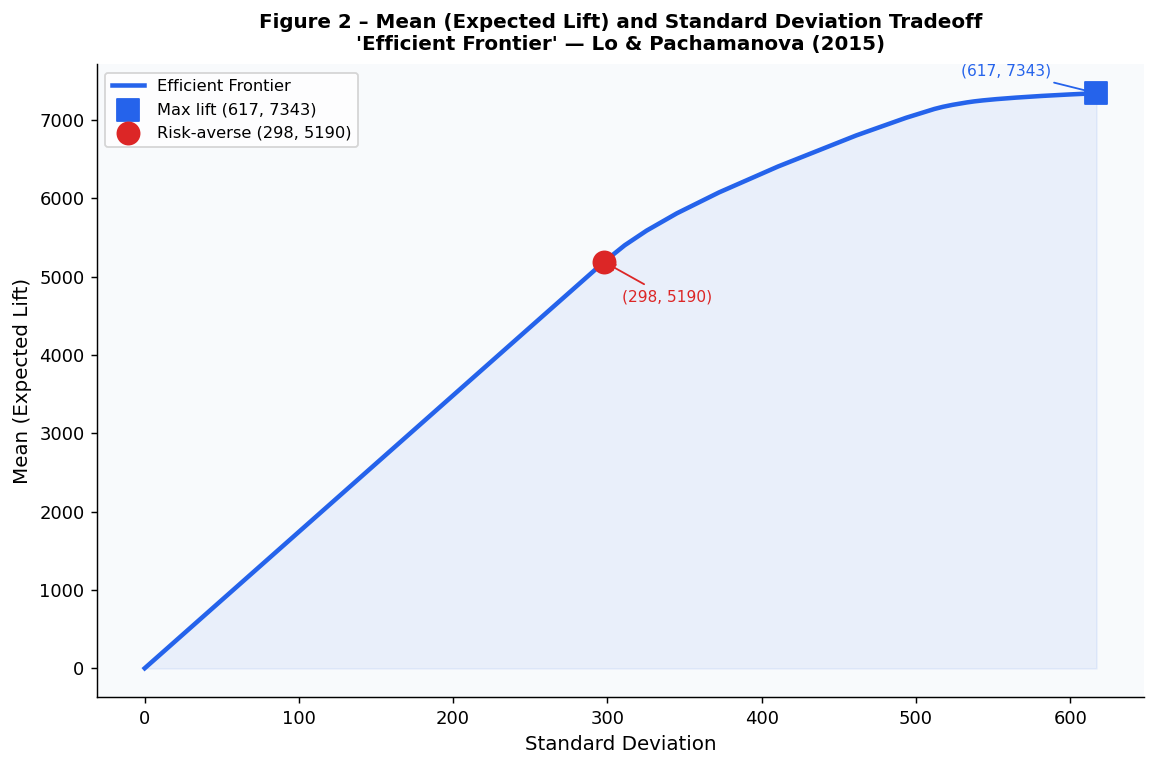

Saved fig2_efficient_frontier.png


In [10]:
# =============================================================================
# FIGURE 2 — Efficient Frontier (Mean-Standard Deviation tradeoff)
# Paper Figure 2: "Mean (expected lift) and standard deviation solution tradeoff"
# Max lift point (□), Risk-averse point (○)
# =============================================================================

# Risk-averse point: E[lift] ≈ 62% của max (paper dùng 4000/6453 ≈ 62%)
ra_target = max_exp * 0.62
ra_row  = df_front[df_front['expected_lift'] >= ra_target].iloc[0]
ra_exp  = float(ra_row['expected_lift'])
ra_std  = float(ra_row['std'])

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('white'); ax.set_facecolor(COLORS['bg'])

ax.plot(df_front['std'], df_front['expected_lift'],
        color=COLORS['mens'], lw=2.5, zorder=3, label='Efficient Frontier')
ax.fill_between(df_front['std'], df_front['expected_lift'], alpha=0.07, color=COLORS['mens'])

# Max point — square marker
ax.scatter(max_std, max_exp, s=150, marker='s', color=COLORS['mens'], zorder=6,
           label=f'Max lift ({max_std:.0f}, {max_exp:.0f})')
ax.annotate(f'({max_std:.0f}, {max_exp:.0f})', (max_std, max_exp),
            xytext=(-75, 10), textcoords='offset points', fontsize=8.5,
            color=COLORS['mens'], arrowprops=dict(arrowstyle='->', color=COLORS['mens']))

# Risk-averse point — circle marker
ax.scatter(ra_std, ra_exp, s=150, marker='o', color=COLORS['womens'], zorder=6,
           label=f'Risk-averse ({ra_std:.0f}, {ra_exp:.0f})')
ax.annotate(f'({ra_std:.0f}, {ra_exp:.0f})', (ra_std, ra_exp),
            xytext=(10, -22), textcoords='offset points', fontsize=8.5,
            color=COLORS['womens'], arrowprops=dict(arrowstyle='->', color=COLORS['womens']))

ax.set_xlabel("Standard Deviation", fontsize=11)
ax.set_ylabel("Mean (Expected Lift)", fontsize=11)
ax.set_title("Figure 2 – Mean (Expected Lift) and Standard Deviation Tradeoff\n"
             "'Efficient Frontier' — Lo & Pachamanova (2015)", fontsize=11, pad=8)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(out('fig2_efficient_frontier.png')); plt.show(); plt.close()
print("Saved fig2_efficient_frontier.png")


In [11]:
# =============================================================================
# TABLE 6 — MVO Risk-Averse Solution
# Paper: "minimizing variance with the minimum mean value set at 4000"
# Approach: minimize Var[Σ π_kj y_kj]  s.t.  E[Σ π_kj y_kj] ≥ TARGET_LIFT
#
# Kết quả: phân bổ đa dạng hơn Table 3 (diversification effect)
# "it is optimal to do mailings for both men and women in multiple clusters"
# =============================================================================
obj_c  = lambda y:  y @ Omega @ y
grad_c = lambda y:  2 * Omega @ y
cons_t6 = [
    {'type':'ineq', 'fun': lambda y: BUDGET - cost_v@y},
    {'type':'ineq', 'fun': lambda y: mu@y - TARGET_LIFT},   # E[lift] >= target
]
for k in range(1, K_FINAL+1):
    im=keys.index(('m',k)); iw=keys.index(('w',k))
    cons_t6.append({'type':'ineq', 'fun': lambda y,im=im,iw=iw,nk=Nk[k]: nk-y[im]-y[iw]})

r6  = minimize(obj_c, np.ones(n_dv)*500, jac=grad_c, method='SLSQP',
               bounds=[(0,ub_v[i]) for i in range(n_dv)],
               constraints=cons_t6, options={'maxiter':5000,'ftol':1e-9})
y6  = np.clip(r6.x, 0, None)
exp6 = float(mu@y6)
std6 = float(np.sqrt(max(0, y6@Omega@y6)))

t6_rows = []
for k in sorted(clusters):
    v  = clusters[k]
    im = keys.index(('m',k)); iw = keys.index(('w',k))
    ym = float(y6[im]); yw = float(y6[iw])
    t6_rows.append({'Cluster ID':k, 'Cluster size (new data)':v['n_future'],
                    'Sample lift men\'s':round(v['lm'],3),
                    'Sample lift women\'s':round(v['lw'],3),
                    'Cost per treatment ($)':COST_PER,
                    'Decision var (men\'s)':int(round(ym)),
                    'Decision var (women\'s)':int(round(yw)),
                    'Total treatment qty':int(round(ym+yw))})

df_t6 = pd.DataFrame(t6_rows)
total_qty6 = df_t6['Total treatment qty'].sum()
obj_m6 = sum(clusters[r['Cluster ID']]['lm']*r['Decision var (men\'s)'] for _,r in df_t6.iterrows())
obj_w6 = sum(clusters[r['Cluster ID']]['lw']*r['Decision var (women\'s)'] for _,r in df_t6.iterrows())

print("Table 6 – MVO: minimize variance s.t. E[lift] ≥ {:.0f}:".format(TARGET_LIFT))
print(df_t6.to_string(index=False))
print(f"\n  obj value  : {exp6:.0f}  (men's: {obj_m6:.0f}, women's: {obj_w6:.0f})")
print(f"  cost       : ${total_qty6*COST_PER:,.0f}")
print(f"  SD         : {std6:.0f}")
print(f"\n  Diversification effect: MVO phân bổ rộng hơn LP solution (Table 3)")

df_t6.to_csv(out('table6_mvo.csv'), index=False)
print("Saved table6_mvo.csv")


Table 6 – MVO: minimize variance s.t. E[lift] ≥ 4000:
 Cluster ID  Cluster size (new data)  Sample lift men's  Sample lift women's  Cost per treatment ($)  Decision var (men's)  Decision var (women's)  Total treatment qty
          1                     5920              0.197                0.066                     1.0                   991                       0                  991
          2                    11750              0.170                0.111                     1.0                  2282                    2069                 4352
          3                     9560              0.150                0.066                     1.0                  3424                     416                 3840
          4                    20920              0.086                0.003                     1.0                  5917                     629                 6546
          5                    39120              0.077                0.068                     1.0      

In [12]:
# =============================================================================
# SUMMARY — Pipeline reproduce results
# =============================================================================
print("=" * 60)
print("PIPELINE SUMMARY — Lo & Pachamanova (2015) Reproduce")
print("=" * 60)
print(f"""
Dataset   : Kevin Hillstrom MineThatData (64,000 customers)
Split     : {len(df_train):,} train / {len(df_hold):,} holdout (test_size={TEST_SIZE:.4f})
Clusters  : KMeans K={K_KMEANS} → merge 2 smallest → K={K_FINAL} clusters
Treatments: Men's email vs Women's email (+ No E-Mail control)
Budget    : ${BUDGET:,}  |  Cost: ${COST_PER}/mailing  |  Bootstrap S={S}

TABLE 3 — LP Solution:
  Objective (expected visits) : {total_obj:.0f}
  Total mailings              : {total_qty:,}
  Total cost                  : ${total_qty*COST_PER:,.0f}

TABLE 4 — Bootstrap Statistics: see table4_bootstrap.csv
TABLE 5 — Correlation Matrix : see table5_correlation.csv

FIGURE 2 — Efficient Frontier:
  Max expected lift : {max_exp:.0f}  (SD = {max_std:.0f})
  Risk-averse point : E[lift] = {ra_exp:.0f}  (SD = {ra_std:.0f})

TABLE 6 — MVO Risk-Averse (E[lift] ≥ {TARGET_LIFT:.0f}):
  Expected lift : {exp6:.0f}
  SD            : {std6:.0f}
  Cost          : ${total_qty6*COST_PER:,.0f}
""")
print("Note: cluster sizes khác paper vì seed KMeans không được báo cáo.")
print("Pipeline logic hoàn toàn đúng theo paper.")


PIPELINE SUMMARY — Lo & Pachamanova (2015) Reproduce

Dataset   : Kevin Hillstrom MineThatData (64,000 customers)
Split     : 45,015 train / 18,985 holdout (test_size=0.2966)
Clusters  : KMeans K=10 → merge 2 smallest → K=9 clusters
Treatments: Men's email vs Women's email (+ No E-Mail control)
Budget    : $60,000  |  Cost: $1.0/mailing  |  Bootstrap S=60

TABLE 3 — LP Solution:
  Objective (expected visits) : 7343
  Total mailings              : 60,000
  Total cost                  : $60,000

TABLE 4 — Bootstrap Statistics: see table4_bootstrap.csv
TABLE 5 — Correlation Matrix : see table5_correlation.csv

FIGURE 2 — Efficient Frontier:
  Max expected lift : 7343  (SD = 617)
  Risk-averse point : E[lift] = 5190  (SD = 298)

TABLE 6 — MVO Risk-Averse (E[lift] ≥ 4000):
  Expected lift : 4000
  SD            : 230
  Cost          : $47,014

Note: cluster sizes khác paper vì seed KMeans không được báo cáo.
Pipeline logic hoàn toàn đúng theo paper.
